<a href="https://colab.research.google.com/github/Swanimadhoop/computer-vision/blob/main/cv_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# *implemnet a sift based image matching between 2 images and visualise the matched key points*

In [ ]:
!pip install opencv-contrib-python matplotlib


Total keypoints in Image 1: 604
Total keypoints in Image 2: 969
Good matches after ratio test: 80


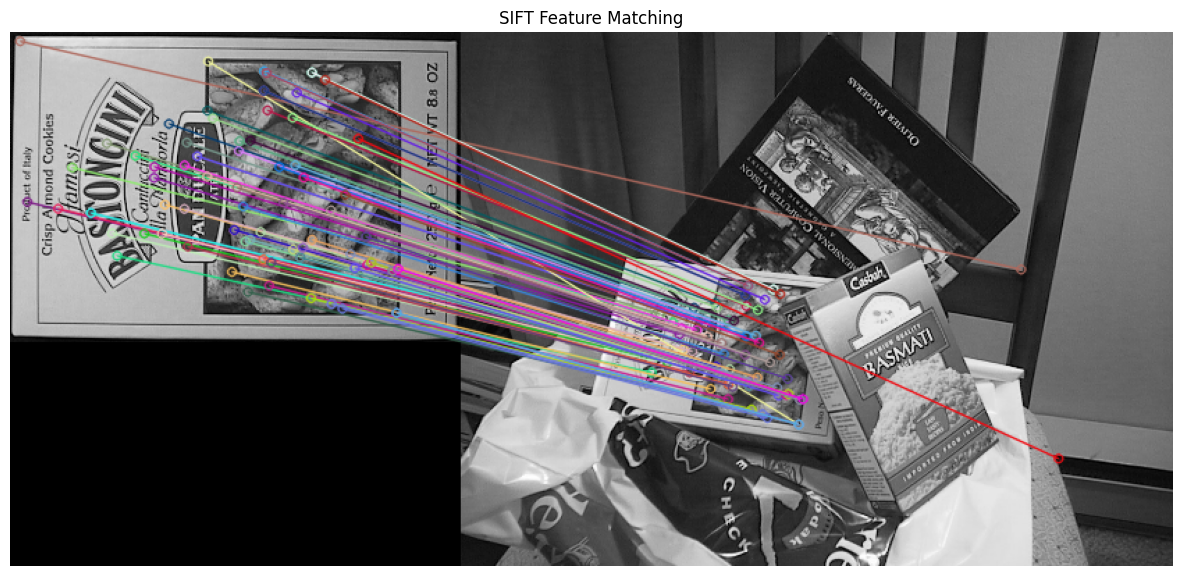

In [ ]:
import cv2
import matplotlib.pyplot as plt


# 1. Load images (grayscale)
img1 = cv2.imread("box.png", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("box_in_scene.png", cv2.IMREAD_GRAYSCALE)

if img1 is None or img2 is None:
    raise ValueError("Could not load input images")

# -----------------------------
# 2. Create SIFT detector
# -----------------------------
sift = cv2.SIFT_create()

# Detect keypoints and descriptors
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

# -----------------------------
# 3. Feature matching (BFMatcher)
# -----------------------------
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)

matches = bf.knnMatch(des1, des2, k=2)

# -----------------------------
# 4. Lowe's Ratio Test
# -----------------------------
good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

print(f"Total keypoints in Image 1: {len(kp1)}")
print(f"Total keypoints in Image 2: {len(kp2)}")
print(f"Good matches after ratio test: {len(good_matches)}")

# -----------------------------
# 5. Draw matches
# -----------------------------
matched_img = cv2.drawMatches(
    img1, kp1,
    img2, kp2,
    good_matches,
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

# -----------------------------
# 6. Visualize
# -----------------------------
plt.figure(figsize=(15, 8))
plt.imshow(matched_img, cmap='gray')
plt.title("SIFT Feature Matching")
plt.axis("off")
plt.show()


# ***implement a pedestrian detection sysytem using HOG and SVM and evaluate the accuracy***

In [ ]:
!pip install opencv-python opencv-contrib-python numpy matplotlib


In [ ]:
import cv2
import numpy as np
import os
from google.colab.patches import cv2_imshow


In [ ]:
!wget -O PennFudanPed.zip https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip
!rm -rf PennFudanPed
!unzip -oq PennFudanPed.zip


--2026-01-30 05:50:20--  https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip
Resolving www.cis.upenn.edu (www.cis.upenn.edu)... 158.130.69.163, 2607:f470:8:64:5ea5::d
Connecting to www.cis.upenn.edu (www.cis.upenn.edu)|158.130.69.163|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 53723336 (51M) [application/zip]
Saving to: ‘PennFudanPed.zip’

PennFudanPed.zip    100%[===================>]  51.23M  61.7MB/s    in 0.8s    

2026-01-30 05:50:21 (61.7 MB/s) - ‘PennFudanPed.zip’ saved [53723336/53723336]



In [ ]:
!ls PennFudanPed


added-object-list.txt  Annotation  PedMasks  PNGImages	readme.txt


In [ ]:
hog = cv2.HOGDescriptor()
hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())


In [ ]:
def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[0] + boxA[2], boxB[0] + boxB[2])
    yB = min(boxA[1] + boxA[3], boxB[1] + boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = boxA[2] * boxA[3]
    boxBArea = boxB[2] * boxB[3]

    return interArea / (boxAArea + boxBArea - interArea + 1e-6)


In [ ]:
import re

def load_ground_truth(txt_file):
    boxes = []
    with open(txt_file, "r") as f:
        for line in f:
            line = line.strip()

            if "Bounding box" in line:
                numbers = list(map(int, re.findall(r'\d+', line)))

                # Take LAST 4 numbers only
                xmin, ymin, xmax, ymax = numbers[-4:]

                w = xmax - xmin
                h = ymax - ymin

                boxes.append((xmin, ymin, w, h))

    return boxes


In [ ]:
TP, FP, FN = 0, 0, 0

image_dir = "PennFudanPed/PNGImages"
anno_dir = "PennFudanPed/Annotation"

image_files = sorted(os.listdir(image_dir))

for img_name in image_files[:25]:   # limit for speed
    img_path = os.path.join(image_dir, img_name)
    txt_path = os.path.join(anno_dir, img_name.replace(".png", ".txt"))

    image = cv2.imread(img_path)
    gt_boxes = load_ground_truth(txt_path)

    detections, _ = hog.detectMultiScale(
        image,
        winStride=(4, 4),
        padding=(8, 8),
        scale=1.03
    )

    matched_gt = set()

    for det in detections:
        matched = False
        for i, gt in enumerate(gt_boxes):
            if compute_iou(det, gt) >= 0.5 and i not in matched_gt:
                TP += 1
                matched_gt.add(i)
                matched = True
                break
        if not matched:
            FP += 1

    FN += len(gt_boxes) - len(matched_gt)


In [ ]:
precision = TP / (TP + FP + 1e-6)
recall = TP / (TP + FN + 1e-6)
f1 = 2 * precision * recall / (precision + recall + 1e-6)

print("===== Evaluation Results =====")
print(f"True Positives : {TP}")
print(f"False Positives: {FP}")
print(f"False Negatives: {FN}")
print(f"Precision      : {precision:.3f}")
print(f"Recall         : {recall:.3f}")
print(f"F1 Score       : {f1:.3f}")


===== Evaluation Results =====
True Positives : 24
False Positives: 26
False Negatives: 21
Precision      : 0.480
Recall         : 0.533
F1 Score       : 0.505


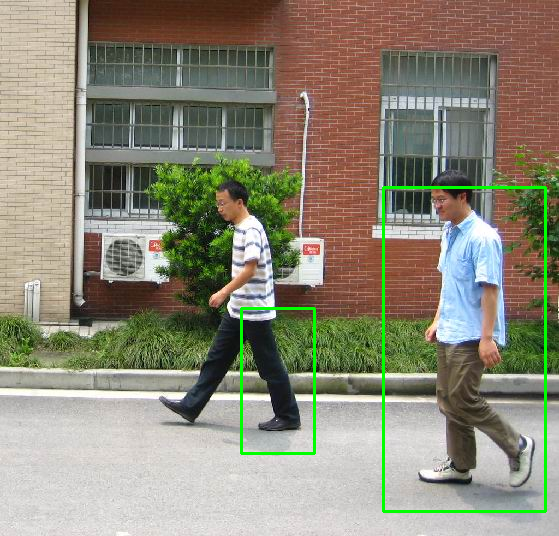

In [ ]:
sample_image = cv2.imread(os.path.join(image_dir, image_files[0]))

detections, _ = hog.detectMultiScale(sample_image)

for (x, y, w, h) in detections:
    cv2.rectangle(sample_image, (x, y), (x+w, y+h), (0, 255, 0), 2)

cv2_imshow(sample_image)


# Design and implement a method to determine whether two shapes are similar using geometric moments.


  Raw Geometric Moments of Triangle
  Area (M00)         : 2204730.0
  Centroid           : (99.8, 111.7)
  Raw M20, M02, M11  : 23526502725.0, 29609523900.0, 24558588450.0
  Central μ20,μ02,μ11: 1588462025.1, 2117765650.0, 182325.0
  Normalized η20     : 0.000327

  Hu Moment Vectors (log-transformed, H1 to H7)

Shape              H1     H2     H3     H4     H5     H6     H7
------------------------------------------------------------
Circle          3.205 10.000 10.000 10.000 -10.000 10.000  0.000
Square          3.185  0.000  0.000  0.000  0.000  0.000  0.000
Triangle        3.118  7.922  9.421  9.993 10.000 10.000 -10.000
Rot.Tri         3.118  7.922  9.421  9.993 10.000 10.000 10.000
ScaledTri       3.118  7.923  9.421  9.993 10.000 10.000 -10.000
Rectangle       3.089  6.628 10.000 10.000 10.000 -10.000 -10.000
Ellipse         3.138  6.850 10.000 10.000 -10.000 -10.000 10.000
Pentagon        3.197  9.944 10.000 10.000 -10.000 -10.000 10.000

  Pairwise Similarity (threshold=0.15

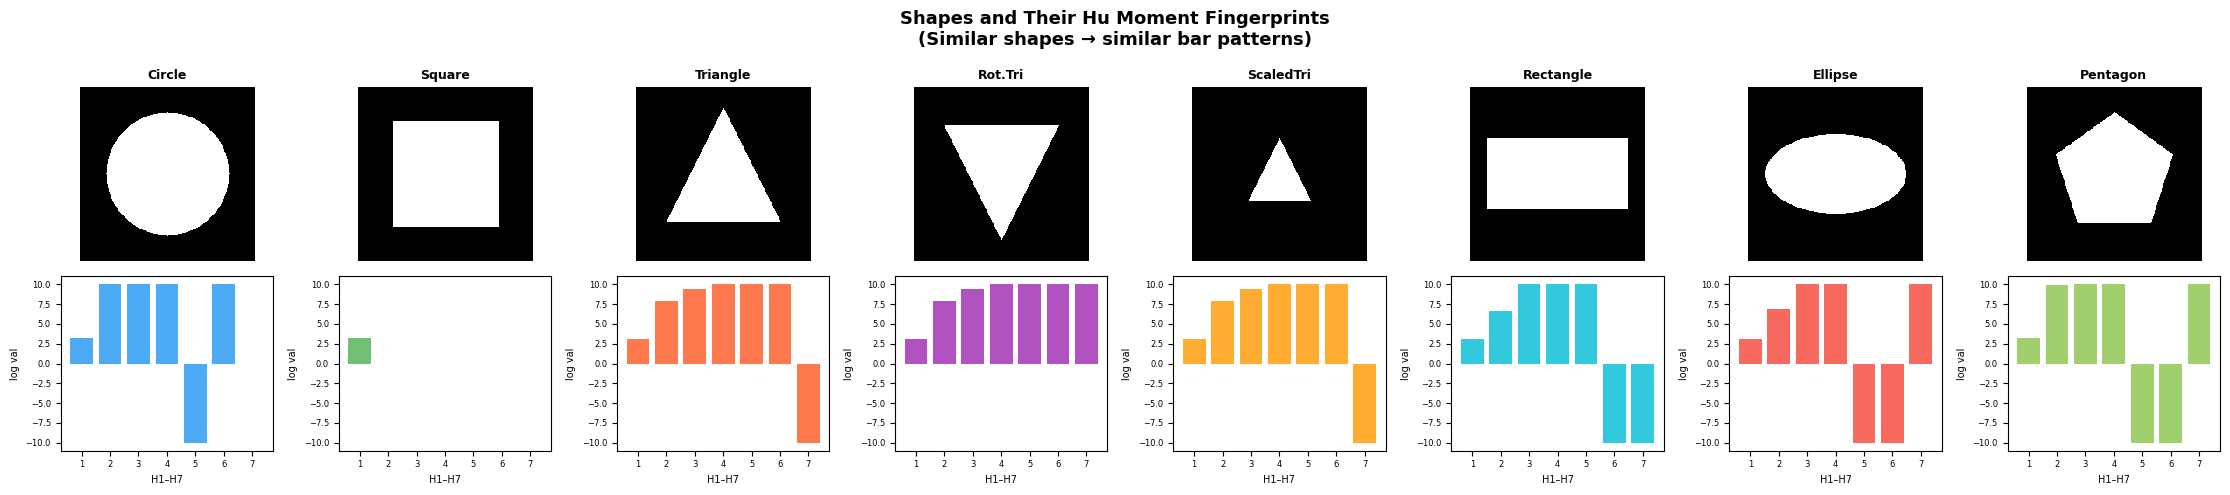

  → Saved: shapes_and_moments.png


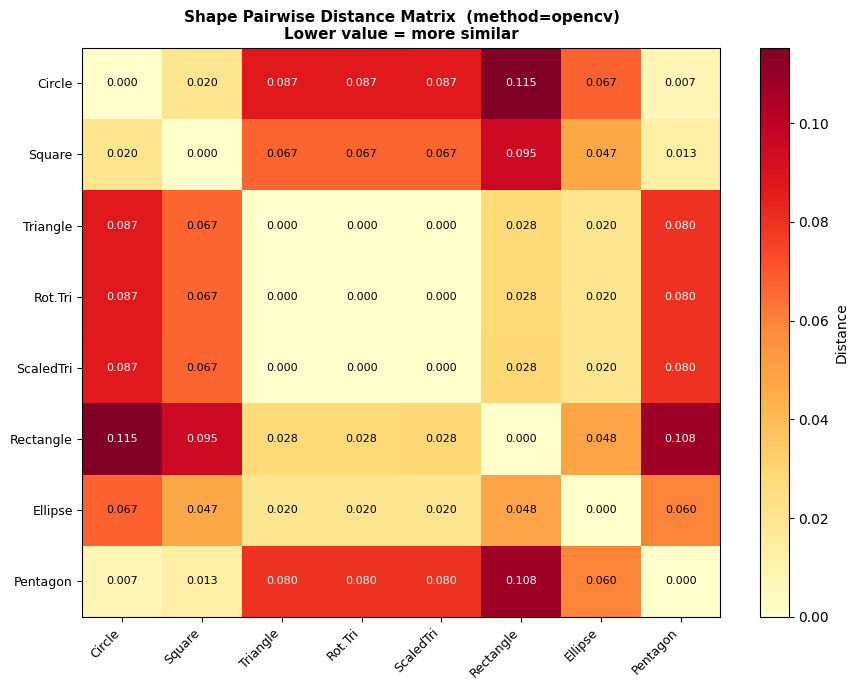

  → Saved: distance_heatmap.png

  Invariance Verification (cv2.matchShapes)
  Translation  — circle at (100,100) vs (150,60):    d=0.000000  ✓ INVARIANT
  Scale        — circle r=50 vs r=25:                d=0.000042  ✓ INVARIANT
  Rotation     — triangle vs triangle rotated 180°:  d=0.000000  ✓ INVARIANT
  Scale        — triangle vs smaller triangle:       d=0.000081  ✓ INVARIANT

  Diff. shape  — circle vs triangle:                 d=0.0869   ✓ DIFFERENT
  Diff. shape  — square vs triangle:                 d=0.0669   ✓ DIFFERENT
  Diff. shape  — circle vs rectangle:                d=0.1153   ✓ DIFFERENT

✓ Done. Check shapes_and_moments.png and distance_heatmap.png



In [1]:

# Shape Similarity using Geometric Moments (Hu Moments)

import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Create Test Shapes

def create_shape(shape_type, size=200):
    """
    Create a binary image (200x200) with a white shape on black background.
    """
    img = np.zeros((size, size), dtype=np.uint8)
    cx, cy = size // 2, size // 2

    if shape_type == 'circle':
        cv2.circle(img, (cx, cy), 70, 255, -1)

    elif shape_type == 'square':
        cv2.rectangle(img, (cx-60, cy-60), (cx+60, cy+60), 255, -1)

    elif shape_type == 'triangle':
        pts = np.array([[cx, cy-75], [cx-65, cy+55], [cx+65, cy+55]], np.int32)
        cv2.fillPoly(img, [pts], 255)

    elif shape_type == 'rotated_triangle':
        # Same triangle rotated 180 degrees
        pts = np.array([[cx, cy+75], [cx-65, cy-55], [cx+65, cy-55]], np.int32)
        cv2.fillPoly(img, [pts], 255)

    elif shape_type == 'scaled_triangle':
        # Same triangle at smaller scale
        pts = np.array([[cx, cy-40], [cx-35, cy+30], [cx+35, cy+30]], np.int32)
        cv2.fillPoly(img, [pts], 255)

    elif shape_type == 'rectangle':
        cv2.rectangle(img, (cx-80, cy-40), (cx+80, cy+40), 255, -1)

    elif shape_type == 'ellipse':
        cv2.ellipse(img, (cx, cy), (80, 45), 0, 0, 360, 255, -1)

    elif shape_type == 'pentagon':
        angles = np.linspace(np.pi/2, np.pi/2 + 2*np.pi, 6)[:-1]
        pts = np.array([[int(cx + 70*np.cos(a)),
                         int(cy - 70*np.sin(a))] for a in angles], np.int32)
        cv2.fillPoly(img, [pts], 255)

    return img


# 2. Compute Raw Geometric Moments (for display/learning)

def explain_moments(binary_image):
    """
    Compute and display the raw, central, and normalized moments
    of a binary shape image for educational purposes.

    Raw moment:     M_pq = Σ_x Σ_y  x^p · y^q · I(x,y)
    Centroid:       x̄ = M10/M00,   ȳ = M01/M00
    Central moment: μ_pq = Σ (x-x̄)^p · (y-ȳ)^q · I(x,y)
    Normalized:     η_pq = μ_pq / (μ_00 ^ ((p+q)/2 + 1))
    """
    M = cv2.moments(binary_image)

    # Area (zeroth moment)
    area = M['m00']

    # Centroid
    if area != 0:
        cx = M['m10'] / area
        cy = M['m01'] / area
    else:
        cx = cy = 0

    print(f"  Area (M00)         : {area:.1f}")
    print(f"  Centroid           : ({cx:.1f}, {cy:.1f})")
    print(f"  Raw M20, M02, M11  : {M['m20']:.1f}, {M['m02']:.1f}, {M['m11']:.1f}")
    print(f"  Central μ20,μ02,μ11: {M['mu20']:.1f}, {M['mu02']:.1f}, {M['mu11']:.1f}")
    print(f"  Normalized η20     : {M['nu20']:.6f}")


# 3. Compute Hu Moments — 7 Invariant Descriptors

def compute_hu_moments(binary_image):
    """
    Hu Moments are 7 scalar values derived from the normalized
    central moments. They are invariant to:

        ✓ Translation  — uses central moments (shifted to centroid)
        ✓ Scale        — uses normalized moments (divided by area)
        ✓ Rotation     — uses specific algebraic combinations
        ✓ Reflection   — 7th moment only (sign changes for mirror)

    Returns log-transformed values for numerical stability.
    log_hu[i] = -sign(hu[i]) * log10(|hu[i]|)
    This maps values like 1e-8 → ~8 instead of 0.00000001
    """
    M = cv2.moments(binary_image)
    hu = cv2.HuMoments(M).flatten()  # shape: (7,)

    # Log transform — makes values easier to compare and visualize
    hu_log = -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)

    return hu_log


# 4. Three Similarity Distance Methods

def similarity_euclidean(hu1, hu2):
    """
    L2 distance between Hu moment vectors.
    Range: [0, ∞)   —   0 = identical
    """
    return float(np.sqrt(np.sum((hu1 - hu2) ** 2)))


def similarity_chi2(hu1, hu2):
    """
    Chi-squared distance — downweights large-valued moments.
    Range: [0, ∞)   —   0 = identical
    """
    eps = 1e-10
    return float(0.5 * np.sum((hu1 - hu2)**2 / (np.abs(hu1) + np.abs(hu2) + eps)))


def similarity_opencv(img1, img2):
    """
    cv2.matchShapes — OpenCV's built-in Hu-moment comparator.
    Uses Method I2:  Σ |1/hu1_i - 1/hu2_i|
    Range: [0, ∞)   —   0 = identical
    Best for general use.
    """
    return cv2.matchShapes(img1, img2, cv2.CONTOURS_MATCH_I2, 0.0)


# 5. Main Decision Function

def are_similar(img1, img2, threshold=0.15, method='opencv'):
    """
    Determine whether two binary shape images are similar.

    Parameters
    ----------
    img1, img2  : np.ndarray   Binary images (uint8, 0 or 255)
    threshold   : float        Max distance to be called "similar"
                               Typical values:
                                   opencv     → 0.10 – 0.20
                                   euclidean  → 1.0  – 3.0
                                   chi2       → 0.05 – 0.20
    method      : str          'opencv' | 'euclidean' | 'chi2'

    Returns
    -------
    (bool, float)   (is_similar, distance)
    """
    if method == 'opencv':
        dist = similarity_opencv(img1, img2)
    else:
        hu1 = compute_hu_moments(img1)
        hu2 = compute_hu_moments(img2)
        if method == 'euclidean':
            dist = similarity_euclidean(hu1, hu2)
        elif method == 'chi2':
            dist = similarity_chi2(hu1, hu2)
        else:
            raise ValueError(f"Unknown method '{method}'. Use: opencv, euclidean, chi2")

    return dist < threshold, dist


# 6. Visualize Shapes + Hu Moment Fingerprints

def visualize_shapes_and_moments(shapes_dict):
    """
    Plot each shape alongside its 7-bar Hu moment fingerprint.
    Similar shapes will have similar bar patterns.
    """
    n = len(shapes_dict)
    fig, axes = plt.subplots(2, n, figsize=(2.8 * n, 5))
    fig.suptitle("Shapes and Their Hu Moment Fingerprints\n"
                 "(Similar shapes → similar bar patterns)",
                 fontsize=13, fontweight='bold')

    colors = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0',
              '#FF9800', '#00BCD4', '#F44336', '#8BC34A']

    for idx, (name, img) in enumerate(shapes_dict.items()):
        # Row 0: shape image
        axes[0, idx].imshow(img, cmap='gray', interpolation='nearest')
        axes[0, idx].set_title(name, fontsize=9, fontweight='bold')
        axes[0, idx].axis('off')

        # Row 1: Hu moment bar chart
        hu = compute_hu_moments(img)
        axes[1, idx].bar(range(1, 8), hu,
                         color=colors[idx % len(colors)], alpha=0.8)
        axes[1, idx].set_xlabel("H1–H7", fontsize=7)
        axes[1, idx].set_ylabel("log val", fontsize=7)
        axes[1, idx].tick_params(labelsize=6)
        axes[1, idx].set_ylim(-11, 11)

    plt.tight_layout()
    plt.savefig("shapes_and_moments.png", dpi=120, bbox_inches='tight')
    plt.show()
    print("  → Saved: shapes_and_moments.png")


# 7. Distance Heatmap

def plot_distance_heatmap(shapes_dict, method='opencv'):
    """
    Compute pairwise distances and display as a color heatmap.
    Darker = more similar, lighter = more different.
    """
    names = list(shapes_dict.keys())
    images = list(shapes_dict.values())
    n = len(names)

    dist_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            _, d = are_similar(images[i], images[j], method=method)
            dist_matrix[i][j] = d

    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(dist_matrix, cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(names, fontsize=9)
    ax.set_title(f"Shape Pairwise Distance Matrix  (method={method})\n"
                 f"Lower value = more similar", fontsize=11, fontweight='bold')
    plt.colorbar(im, ax=ax, label="Distance")

    for i in range(n):
        for j in range(n):
            color = 'white' if dist_matrix[i][j] > dist_matrix.max() * 0.6 else 'black'
            ax.text(j, i, f"{dist_matrix[i][j]:.3f}",
                    ha='center', va='center', fontsize=8, color=color)

    plt.tight_layout()
    plt.savefig("distance_heatmap.png", dpi=120, bbox_inches='tight')
    plt.show()
    print("  → Saved: distance_heatmap.png")

    return dist_matrix


# 8. Prove Invariance Properties

def demonstrate_invariance():
    """
    Empirically verify that Hu moments are invariant to
    translation, scale, and rotation.
    """
    print(f"\n{'='*65}")
    print("  Invariance Verification (cv2.matchShapes)")
    print(f"{'='*65}")

    # Translation invariance
    a = np.zeros((200, 200), dtype=np.uint8)
    cv2.circle(a, (100, 100), 50, 255, -1)
    b = np.zeros((200, 200), dtype=np.uint8)
    cv2.circle(b, (150, 60), 50, 255, -1)       # shifted center
    d = cv2.matchShapes(a, b, cv2.CONTOURS_MATCH_I2, 0)
    print(f"  Translation  — circle at (100,100) vs (150,60):    d={d:.6f}  {'✓ INVARIANT' if d < 0.001 else '✗'}")

    # Scale invariance
    c = np.zeros((200, 200), dtype=np.uint8)
    cv2.circle(c, (100, 100), 25, 255, -1)       # half radius
    d = cv2.matchShapes(a, c, cv2.CONTOURS_MATCH_I2, 0)
    print(f"  Scale        — circle r=50 vs r=25:                d={d:.6f}  {'✓ INVARIANT' if d < 0.001 else '✗'}")

    # Rotation invariance
    t1 = create_shape('triangle')
    t2 = create_shape('rotated_triangle')
    d = cv2.matchShapes(t1, t2, cv2.CONTOURS_MATCH_I2, 0)
    print(f"  Rotation     — triangle vs triangle rotated 180°:  d={d:.6f}  {'✓ INVARIANT' if d < 0.001 else '✗'}")

    # Scale + shape
    t3 = create_shape('scaled_triangle')
    d = cv2.matchShapes(t1, t3, cv2.CONTOURS_MATCH_I2, 0)
    print(f"  Scale        — triangle vs smaller triangle:       d={d:.6f}  {'✓ INVARIANT' if d < 0.01 else '✗'}")

    # Different shapes — should NOT match
    print()
    d = cv2.matchShapes(create_shape('circle'),   create_shape('triangle'),  cv2.CONTOURS_MATCH_I2, 0)
    print(f"  Diff. shape  — circle vs triangle:                 d={d:.4f}   {'✓ DIFFERENT' if d > 0.05 else '✗ falsely similar'}")
    d = cv2.matchShapes(create_shape('square'),   create_shape('triangle'),  cv2.CONTOURS_MATCH_I2, 0)
    print(f"  Diff. shape  — square vs triangle:                 d={d:.4f}   {'✓ DIFFERENT' if d > 0.05 else '✗ falsely similar'}")
    d = cv2.matchShapes(create_shape('circle'),   create_shape('rectangle'), cv2.CONTOURS_MATCH_I2, 0)
    print(f"  Diff. shape  — circle vs rectangle:                d={d:.4f}   {'✓ DIFFERENT' if d > 0.05 else '✗ falsely similar'}")


# 9. MAIN

if __name__ == "__main__":

    shapes = {
        'Circle':       create_shape('circle'),
        'Square':       create_shape('square'),
        'Triangle':     create_shape('triangle'),
        'Rot.Tri':      create_shape('rotated_triangle'),
        'ScaledTri':    create_shape('scaled_triangle'),
        'Rectangle':    create_shape('rectangle'),
        'Ellipse':      create_shape('ellipse'),
        'Pentagon':     create_shape('pentagon'),
    }

    # ── 1. Explain raw moments for one shape
    print("\n" + "="*65)
    print("  Raw Geometric Moments of Triangle")
    print("="*65)
    explain_moments(shapes['Triangle'])

    # ── 2. Print Hu moment table for all shapes
    print("\n" + "="*65)
    print("  Hu Moment Vectors (log-transformed, H1 to H7)")
    print("="*65)
    print(f"\n{'Shape':<14}", end="")
    for i in range(1, 8):
        print(f"     H{i}", end="")
    print()
    print("-" * 60)
    for name, img in shapes.items():
        hu = compute_hu_moments(img)
        print(f"{name:<14}", end="")
        for v in hu:
            print(f" {v:6.3f}", end="")
        print()

    # ── 3. Direct pairwise similarity checks
    print("\n" + "="*65)
    print("  Pairwise Similarity (threshold=0.15, method=opencv)")
    print("="*65)
    pairs = [
        ('Triangle',    'Rot.Tri',    "same shape, rotated 180°"),
        ('Triangle',    'ScaledTri',  "same shape, smaller scale"),
        ('Circle',      'Ellipse',    "similar family (curved)"),
        ('Square',      'Rectangle',  "similar family (rectangular)"),
        ('Square',      'Pentagon',   "both polygons, but different"),
        ('Circle',      'Triangle',   "clearly different"),
        ('Circle',      'Square',     "clearly different"),
        ('Triangle',    'Pentagon',   "both polygons, different"),
    ]
    for n1, n2, note in pairs:
        similar, dist = are_similar(shapes[n1], shapes[n2],
                                    threshold=0.15, method='opencv')
        tag = "SIMILAR  ✓" if similar else "DIFFERENT ✗"
        print(f"  {n1:<12} vs {n2:<12} | dist={dist:.4f} | {tag}  ({note})")

    # ── 4. Visualize shapes and their moment fingerprints
    print("\nGenerating visualizations...")
    visualize_shapes_and_moments(shapes)

    # ── 5. Distance heatmap
    plot_distance_heatmap(shapes, method='opencv')

    # ── 6. Prove invariance
    demonstrate_invariance()

    print("\n✓ Done. Check shapes_and_moments.png and distance_heatmap.png\n")

# ***`Implement block matching using SAD(Sum of absolute Differences) to estimate motion between two images`***


  Block Matching — SAD Motion Estimation

  Frame size  : (120, 160)
  Block size  : 16 x 16 pixels
  Search range: ± 8 pixels

  Running Full Search (exhaustive)...
  PSNR (Full Search) : 23.48 dB

  Full Search Motion Vectors
  ─────────────────────────────────────────────
  Total blocks           : 70
  dx  — mean=+2.20,  min=-8,  max=+8
  dy  — mean=+2.71,  min=-8,  max=+8
  Magnitude — mean=7.59,  max=11.31
  Zero vectors (static)  : 0

  Running Three-Step Search (TSS)...
  PSNR (TSS)         : 21.48 dB

  Three-Step Search Motion Vectors
  ─────────────────────────────────────────────
  Total blocks           : 70
  dx  — mean=+2.33,  min=-7,  max=+7
  dy  — mean=+1.57,  min=-7,  max=+7
  Magnitude — mean=5.85,  max=9.22
  Zero vectors (static)  : 1

  Complexity Comparison (per block, SR=8):
  Full Search : (2×8+1)² = 289 SAD computations
  TSS         : ~25 SAD computations  (11x speedup)

  Plotting SAD surface for block at (20, 20)...


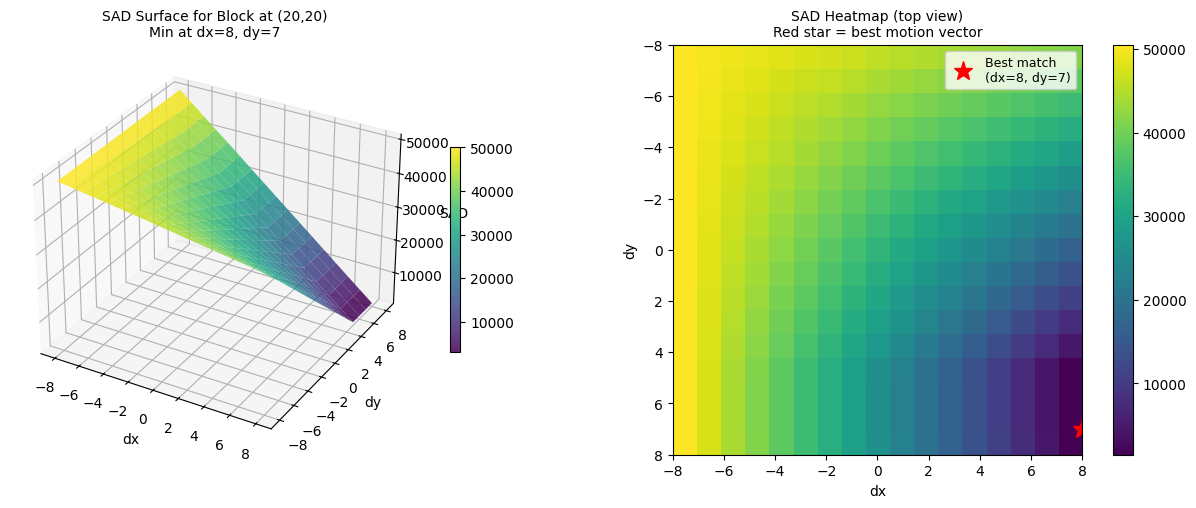

  → Saved: sad_surface.png
  Estimated motion for block (20,20): dx=8, dy=7

  Generating results dashboard...


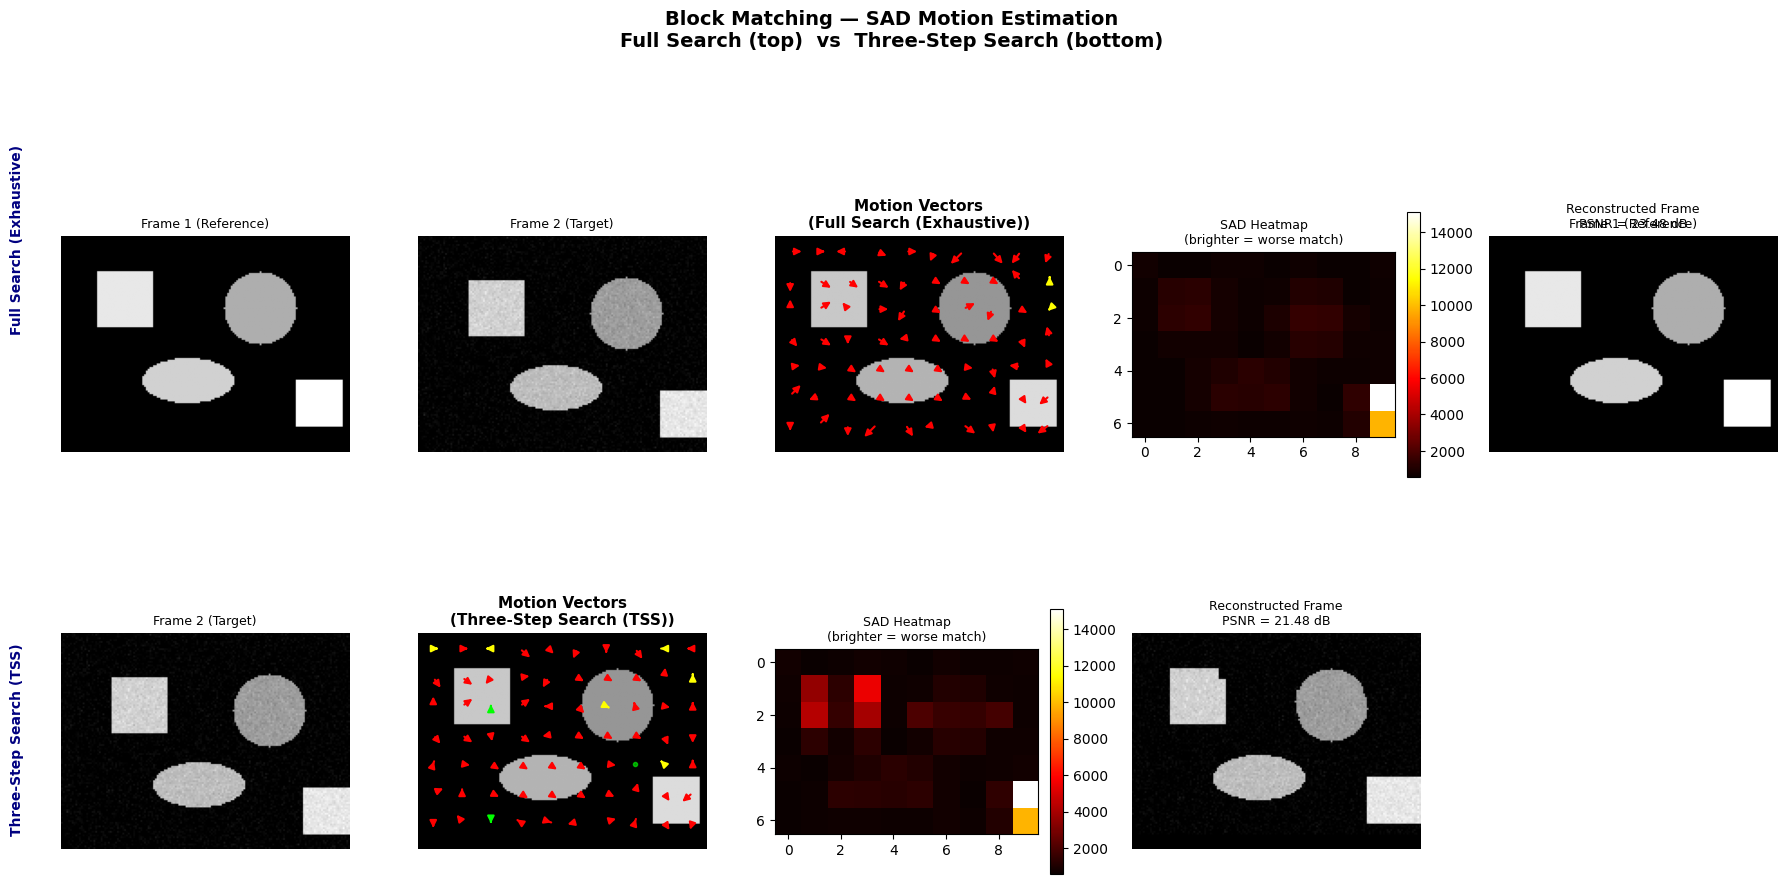

  → Saved: block_matching_results.png

  ✓ Done.



In [3]:

# Block Matching using SAD (Sum of Absolute Differences)
# Motion Estimation between Two Frames

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. Create Synthetic Test Frames

def create_test_frames(height=120, width=160):
    # ── Frame 1: Reference ──────────────────────────────────
    frame1 = np.zeros((height, width), dtype=np.uint8)

    # Rectangle object
    cv2.rectangle(frame1, (20, 20), (50, 50), 200, -1)

    # Circle object
    cv2.circle(frame1, (110, 40), 20, 150, -1)

    # Ellipse object
    cv2.ellipse(frame1, (70, 80), (25, 12), 0, 0, 360, 180, -1)

    # Small square
    cv2.rectangle(frame1, (130, 80), (155, 105), 220, -1)

    # ── Frame 2: Target (with motion applied) ───────────────
    frame2 = np.zeros((height, width), dtype=np.uint8)

    # Rectangle moved (+8, +5)  →  motion vector (8, 5)
    cv2.rectangle(frame2, (28, 25), (58, 55), 200, -1)

    # Circle moved (+5, +3)
    cv2.circle(frame2, (115, 43), 20, 150, -1)

    # Ellipse moved (+6, +4)
    cv2.ellipse(frame2, (76, 84), (25, 12), 0, 0, 360, 180, -1)

    # Small square moved (+4, +6)
    cv2.rectangle(frame2, (134, 86), (159, 111), 220, -1)

    # Add mild Gaussian noise to make it realistic
    noise = np.random.normal(0, 8, frame2.shape).astype(np.int16)
    frame2 = np.clip(frame2.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    return frame1, frame2


# 2. SAD Computation (Core Building Block)

def compute_SAD(block1, block2):
    return float(np.sum(np.abs(block1.astype(np.int16)
                               - block2.astype(np.int16))))


# 3. Full Search Block Matching (Exhaustive)

def full_search_block_matching(frame1, frame2,
                                block_size=16, search_range=8):

    h, w = frame1.shape
    BS = block_size
    SR = search_range

    motion_vectors = {}
    sad_map_list   = []

    # Slide the block grid over frame1
    block_rows = []
    for by in range(0, h - BS + 1, BS):
        row = []
        for bx in range(0, w - BS + 1, BS):

            ref_block = frame1[by:by+BS, bx:bx+BS]

            best_SAD = float('inf')
            best_dx, best_dy = 0, 0

            # ── Exhaustive search within ±SR ──────────────
            for dy in range(-SR, SR + 1):
                for dx in range(-SR, SR + 1):

                    # Candidate top-left in frame2
                    cy2 = by + dy
                    cx2 = bx + dx

                    # Boundary check — skip if outside frame2
                    if cy2 < 0 or cx2 < 0:
                        continue
                    if cy2 + BS > h or cx2 + BS > w:
                        continue

                    cand_block = frame2[cy2:cy2+BS, cx2:cx2+BS]

                    sad = compute_SAD(ref_block, cand_block)

                    if sad < best_SAD:
                        best_SAD  = sad
                        best_dx   = dx
                        best_dy   = dy

            motion_vectors[(bx, by)] = (best_dx, best_dy)
            row.append(best_SAD)

        block_rows.append(row)

    sad_map = np.array(block_rows, dtype=np.float32)

    return motion_vectors, sad_map


# 4. Three-Step Search (TSS) — Faster Approximation

def three_step_search(frame1, frame2,
                      block_size=16, search_range=8):
    h, w = frame1.shape
    BS   = block_size
    SR   = search_range

    motion_vectors = {}
    sad_map_rows   = []

    for by in range(0, h - BS + 1, BS):
        row = []
        for bx in range(0, w - BS + 1, BS):

            ref_block = frame1[by:by+BS, bx:bx+BS]

            # Start at block center
            cx, cy = bx, by
            step = max(1, SR // 2)

            best_SAD = float('inf')

            # Run 3 search steps
            for _ in range(3):
                # 8 surrounding points + current center
                candidates = [(cx + dx, cy + dy)
                              for dy in [-step, 0, step]
                              for dx in [-step, 0, step]]

                for (tx, ty) in candidates:
                    # Boundary check
                    if ty < 0 or tx < 0: continue
                    if ty + BS > h or tx + BS > w: continue

                    sad = compute_SAD(ref_block, frame2[ty:ty+BS, tx:tx+BS])

                    if sad < best_SAD:
                        best_SAD = sad
                        cx, cy   = tx, ty

                step = max(1, step // 2)

            motion_vectors[(bx, by)] = (cx - bx, cy - by)
            row.append(best_SAD)

        sad_map_rows.append(row)

    sad_map = np.array(sad_map_rows, dtype=np.float32)
    return motion_vectors, sad_map


# 5. Reconstruct Frame from Motion Vectors

def reconstruct_frame(frame2, motion_vectors, block_size=16):
    BS = block_size
    h2, w2 = frame2.shape
    reconstructed = np.zeros_like(frame2)

    for (bx, by), (dx, dy) in motion_vectors.items():
        src_y = by + dy
        src_x = bx + dx

        # Clamp to valid region
        src_y = max(0, min(src_y, h2 - BS))
        src_x = max(0, min(src_x, w2 - BS))

        reconstructed[by:by+BS, bx:bx+BS] = \
            frame2[src_y:src_y+BS, src_x:src_x+BS]

    return reconstructed


# 6. Compute PSNR — Quality Metric

def compute_psnr(img1, img2):
    mse = np.mean((img1.astype(np.float32) - img2.astype(np.float32)) ** 2)
    if mse == 0:
        return float('inf')
    return 10 * np.log10(255.0 ** 2 / mse)


# 7. Visualize Motion Vectors (Quiver Plot)

def visualize_motion_vectors(frame1, motion_vectors,
                              block_size=16, title="Motion Vectors", ax=None):
    BS = block_size
    show = ax is None
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))

    ax.imshow(frame1, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=11, fontweight='bold')

    for (bx, by), (dx, dy) in motion_vectors.items():
        # Arrow starts from block center
        start_x = bx + BS // 2
        start_y = by + BS // 2

        magnitude = np.sqrt(dx**2 + dy**2)
        color = 'red' if magnitude > 3 else ('yellow' if magnitude > 1 else 'lime')

        if dx != 0 or dy != 0:
            ax.annotate("",
                xy=(start_x + dx, start_y + dy),
                xytext=(start_x, start_y),
                arrowprops=dict(arrowstyle="-|>",
                                color=color, lw=1.5,
                                mutation_scale=10))
        else:
            ax.plot(start_x, start_y, 'o', color='lime',
                    markersize=3, alpha=0.6)

    if show:
        plt.tight_layout()
        plt.show()


# 8. Full Visualization Dashboard

def visualize_results(frame1, frame2,
                       mv_full, sad_full, recon_full,
                       mv_tss,  sad_tss,  recon_tss,
                       block_size=16):
    fig = plt.figure(figsize=(18, 10))
    fig.suptitle("Block Matching — SAD Motion Estimation\n"
                 "Full Search (top)  vs  Three-Step Search (bottom)",
                 fontsize=14, fontweight='bold')

    psnr_full = compute_psnr(frame1, recon_full)
    psnr_tss  = compute_psnr(frame1, recon_tss)

    # ── Row labels ───────────────────────────────────────────
    for row, (mv, sad_map, recon, method, psnr) in enumerate([
        (mv_full, sad_full, recon_full, "Full Search (Exhaustive)", psnr_full),
        (mv_tss,  sad_tss,  recon_tss,  "Three-Step Search (TSS)", psnr_tss),
    ]):
        offset = row * 4

        # Col 1: Reference frame
        ax1 = fig.add_subplot(2, 5, offset + 1)
        ax1.imshow(frame1, cmap='gray')
        ax1.set_title("Frame 1 (Reference)", fontsize=9)
        ax1.axis('off')

        # Col 2: Target frame
        ax2 = fig.add_subplot(2, 5, offset + 2)
        ax2.imshow(frame2, cmap='gray')
        ax2.set_title("Frame 2 (Target)", fontsize=9)
        ax2.axis('off')

        # Col 3: Motion vectors
        ax3 = fig.add_subplot(2, 5, offset + 3)
        visualize_motion_vectors(frame1, mv,
                                  block_size=block_size,
                                  title=f"Motion Vectors\n({method})",
                                  ax=ax3)
        ax3.axis('off')

        # Col 4: SAD heatmap
        ax4 = fig.add_subplot(2, 5, offset + 4)
        im = ax4.imshow(sad_map, cmap='hot', interpolation='nearest')
        ax4.set_title(f"SAD Heatmap\n(brighter = worse match)", fontsize=9)
        plt.colorbar(im, ax=ax4, fraction=0.046, pad=0.04)

        # Col 5: Reconstructed frame
        ax5 = fig.add_subplot(2, 5, offset + 5)
        ax5.imshow(recon, cmap='gray')
        ax5.set_title(f"Reconstructed Frame\nPSNR = {psnr:.2f} dB", fontsize=9)
        ax5.axis('off')

        # Row label
        fig.text(0.01, 0.75 - row * 0.5, method,
                 fontsize=10, color='navy', fontweight='bold',
                 rotation=90, va='center')

    plt.tight_layout(rect=[0.03, 0, 1, 0.95])
    plt.savefig("block_matching_results.png", dpi=130, bbox_inches='tight')
    plt.show()
    print("  → Saved: block_matching_results.png")


# 9. SAD Surface Plot for One Block (Educational)

def plot_sad_surface(frame1, frame2,
                     block_x=20, block_y=20,
                     block_size=16, search_range=8):
    BS = block_size
    SR = search_range
    h, w = frame1.shape

    ref_block = frame1[block_y:block_y+BS, block_x:block_x+BS]

    displacements = range(-SR, SR + 1)
    sad_surface   = np.zeros((len(displacements), len(displacements)))

    for i, dy in enumerate(displacements):
        for j, dx in enumerate(displacements):
            cy2, cx2 = block_y + dy, block_x + dx
            if cy2 < 0 or cx2 < 0 or cy2+BS > h or cx2+BS > w:
                sad_surface[i, j] = np.nan
            else:
                sad_surface[i, j] = compute_SAD(
                    ref_block, frame2[cy2:cy2+BS, cx2:cx2+BS])

    # Find the minimum (= best match)
    flat_idx = np.nanargmin(sad_surface)
    min_i, min_j = np.unravel_index(flat_idx, sad_surface.shape)
    best_dy = list(displacements)[min_i]
    best_dx = list(displacements)[min_j]

    # Plot
    fig = plt.figure(figsize=(13, 5))

    # 3D surface
    ax1 = fig.add_subplot(121, projection='3d')
    X, Y = np.meshgrid(list(displacements), list(displacements))
    surf = ax1.plot_surface(X, Y, sad_surface,
                             cmap='viridis', alpha=0.85, edgecolor='none')
    ax1.set_xlabel("dx"); ax1.set_ylabel("dy"); ax1.set_zlabel("SAD")
    ax1.set_title(f"SAD Surface for Block at ({block_x},{block_y})\n"
                  f"Min at dx={best_dx}, dy={best_dy}", fontsize=10)
    fig.colorbar(surf, ax=ax1, shrink=0.5)

    # 2D heatmap (top view)
    ax2 = fig.add_subplot(122)
    im = ax2.imshow(sad_surface, cmap='viridis',
                    extent=[-SR, SR, SR, -SR], origin='upper')
    ax2.plot(best_dx, best_dy, 'r*', markersize=14,
             label=f"Best match\n(dx={best_dx}, dy={best_dy})")
    ax2.set_xlabel("dx"); ax2.set_ylabel("dy")
    ax2.set_title("SAD Heatmap (top view)\nRed star = best motion vector", fontsize=10)
    ax2.legend(fontsize=9)
    plt.colorbar(im, ax=ax2)

    plt.tight_layout()
    plt.savefig("sad_surface.png", dpi=120, bbox_inches='tight')
    plt.show()
    print("  → Saved: sad_surface.png")

    return best_dx, best_dy


# 10. Print Motion Vector Statistics

def print_mv_stats(motion_vectors, label=""):
    dx_vals = [v[0] for v in motion_vectors.values()]
    dy_vals = [v[1] for v in motion_vectors.values()]
    magnitudes = [np.sqrt(dx**2 + dy**2) for dx, dy in motion_vectors.values()]

    print(f"\n  {label}")
    print(f"  {'─'*45}")
    print(f"  Total blocks           : {len(motion_vectors)}")
    print(f"  dx  — mean={np.mean(dx_vals):+.2f},  "
          f"min={min(dx_vals):+d},  max={max(dx_vals):+d}")
    print(f"  dy  — mean={np.mean(dy_vals):+.2f},  "
          f"min={min(dy_vals):+d},  max={max(dy_vals):+d}")
    print(f"  Magnitude — mean={np.mean(magnitudes):.2f},  "
          f"max={max(magnitudes):.2f}")
    print(f"  Zero vectors (static)  : "
          f"{sum(1 for d in motion_vectors.values() if d==(0,0))}")


# 11. MAIN

if __name__ == "__main__":

    np.random.seed(42)

    # ── Create synthetic test frames ─────────────────────────
    print("\n" + "="*55)
    print("  Block Matching — SAD Motion Estimation")
    print("="*55)

    frame1, frame2 = create_test_frames(height=120, width=160)

    print(f"\n  Frame size  : {frame1.shape}")
    print(f"  Block size  : 16 x 16 pixels")
    print(f"  Search range: ± 8 pixels")

    BS = 16   # block size
    SR = 8    # search range

    # ── Full Search Block Matching ───────────────────────────
    print("\n  Running Full Search (exhaustive)...")
    mv_full, sad_full = full_search_block_matching(
        frame1, frame2, block_size=BS, search_range=SR)
    recon_full = reconstruct_frame(frame2, mv_full, block_size=BS)

    print(f"  PSNR (Full Search) : {compute_psnr(frame1, recon_full):.2f} dB")
    print_mv_stats(mv_full, "Full Search Motion Vectors")

    # ── Three-Step Search ────────────────────────────────────
    print("\n  Running Three-Step Search (TSS)...")
    mv_tss, sad_tss = three_step_search(
        frame1, frame2, block_size=BS, search_range=SR)
    recon_tss = reconstruct_frame(frame2, mv_tss, block_size=BS)

    print(f"  PSNR (TSS)         : {compute_psnr(frame1, recon_tss):.2f} dB")
    print_mv_stats(mv_tss, "Three-Step Search Motion Vectors")

    # ── Complexity Comparison ────────────────────────────────
    print(f"\n  Complexity Comparison (per block, SR={SR}):")
    print(f"  Full Search : (2×{SR}+1)² = {(2*SR+1)**2} SAD computations")
    print(f"  TSS         : ~25 SAD computations  "
          f"({(2*SR+1)**2 // 25}x speedup)")

    # ── SAD Surface for one block ────────────────────────────
    print("\n  Plotting SAD surface for block at (20, 20)...")
    best_dx, best_dy = plot_sad_surface(
        frame1, frame2, block_x=20, block_y=20,
        block_size=BS, search_range=SR)
    print(f"  Estimated motion for block (20,20): "
          f"dx={best_dx}, dy={best_dy}")

    # ── Full results dashboard ───────────────────────────────
    print("\n  Generating results dashboard...")
    visualize_results(frame1, frame2,
                      mv_full, sad_full, recon_full,
                      mv_tss,  sad_tss,  recon_tss,
                      block_size=BS)

    print("\n  ✓ Done.\n")

# ***`Implement 2D Image registration b/w wo imaghe using feature matching. Implement affine transformations on an image. Recognize an object in a scene using local feature matching`***


  Computer Vision — Feature Matching Pipeline

────────────────────────────────────────────────────────────
  PART 1 — 2D Image Registration
────────────────────────────────────────────────────────────

  [Registration] Detecting features with ORB...
  Keypoints: img1=1884, img2=1834
  Good matches after ratio test: 470
  [Registration] Estimating affine transform (RANSAC)...
  RANSAC inliers: 117 / 470 matches
  NCC before registration: 0.2242
  NCC after  registration: 0.9025  (1.0 = perfect alignment)


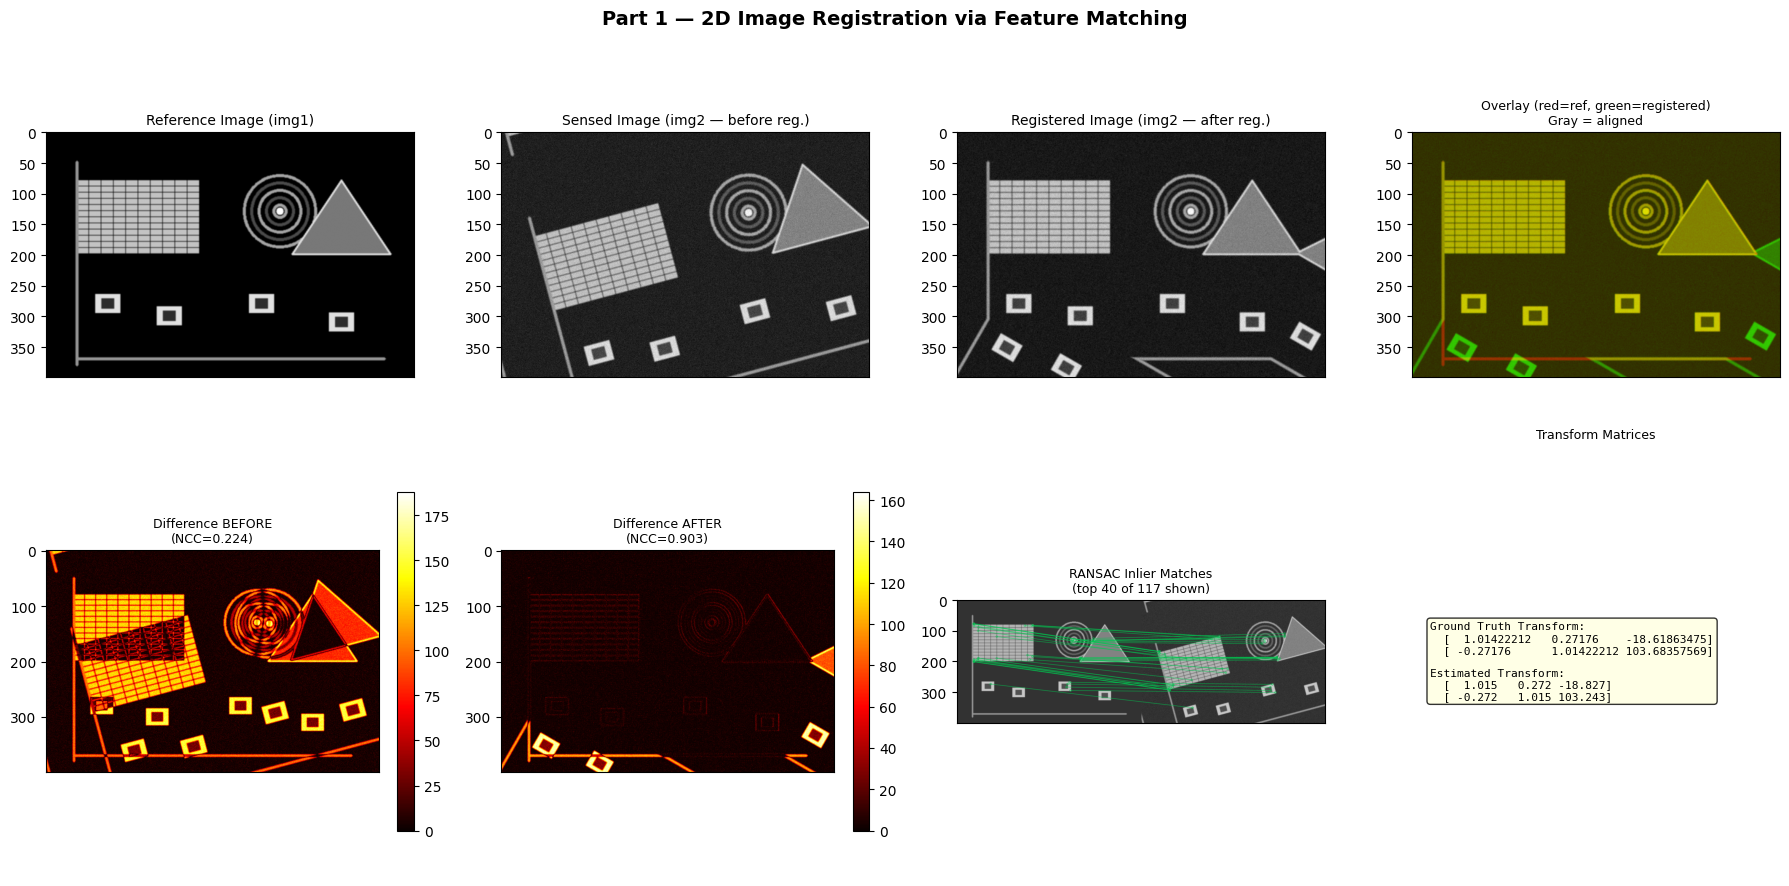

  → Saved: image_registration.png

────────────────────────────────────────────────────────────
  PART 2 — Affine Transformations
────────────────────────────────────────────────────────────


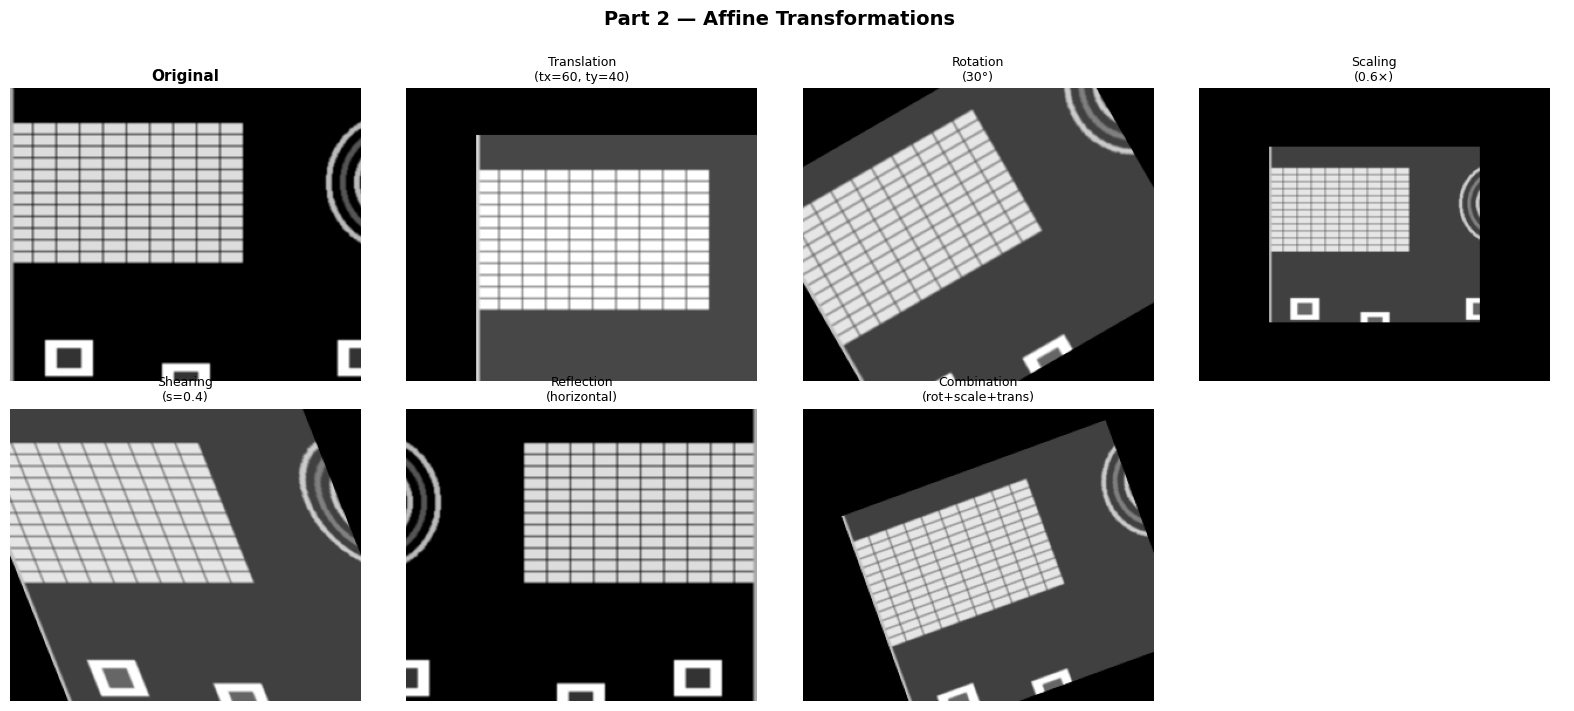

  → Saved: affine_transforms.png

  Rotation matrix:
[[  0.906   0.423 -38.773]
 [ -0.423   0.906  75.104]]

  Translation matrix:
[[ 1.  0. 30.]
 [ 0.  1. 20.]]

  Composed (rot then trans):
[[ 0.906  0.423 -8.773]
 [-0.423  0.906 95.104]]

────────────────────────────────────────────────────────────
  PART 3 — Object Recognition in Scene
────────────────────────────────────────────────────────────
  Template size: (120, 200)
  Scene size   : (400, 600)
  Template was cropped from scene at x=50, y=80, w=200, h=120

  [Object Recognition] method=ORB
  Keypoints: img1=657, img2=3634
  Good matches after ratio test: 252
  ✓ Object FOUND — 11 inlier matches


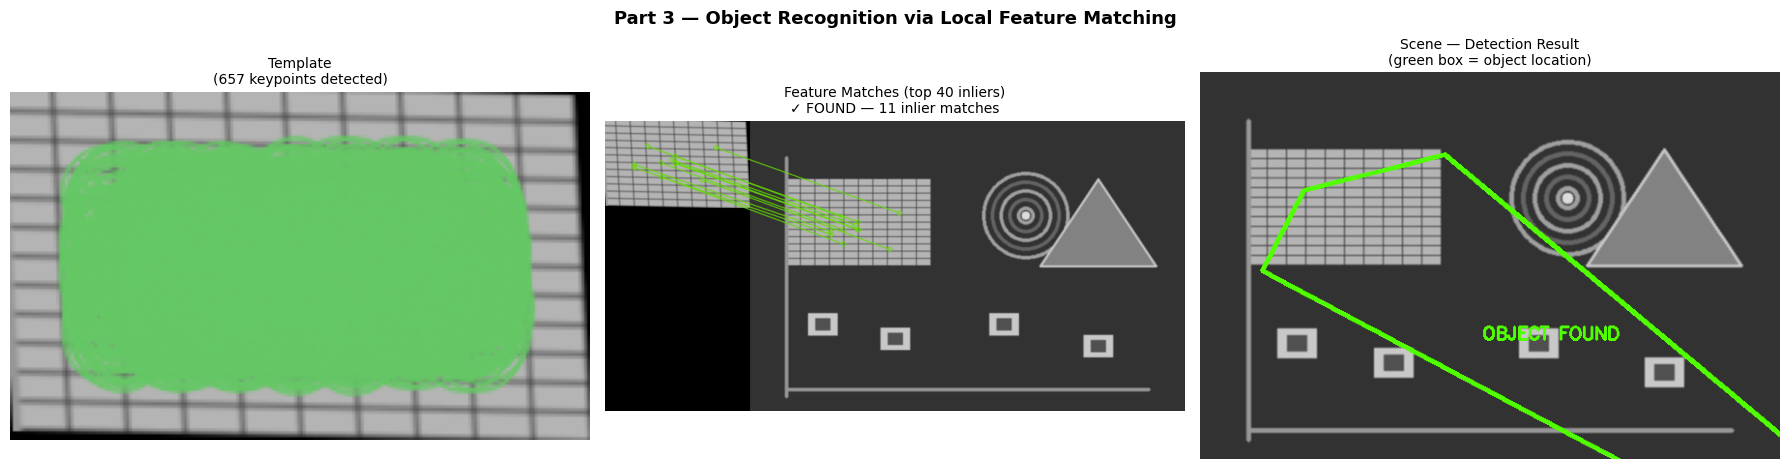

  → Saved: object_recognition.png

  Summary
  Part 1 — Registration NCC improvement: 0.224 → 0.903
  Part 2 — 6 affine transforms applied successfully
  Part 3 — Object FOUND ✓ (11 inlier matches)

  Output files:
    image_registration.png
    affine_transforms.png
    object_recognition.png



In [5]:

# 2D Image Registration, Affine Transformation &
# Object Recognition using Feature Matching

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import ConnectionPatch

# PART 1 — Create Synthetic Test Images

def create_base_scene(h=400, w=600):
    img = np.ones((h, w), dtype=np.uint8) * 50  # dark gray background

    # Textured rectangle (brick-like pattern)
    for i in range(80, 200, 10):
        for j in range(50, 250, 20):
            cv2.rectangle(img, (j, i), (j+18, i+8), 180, -1)

    # Circular object with radial texture
    for r in range(10, 70, 12):
        cv2.circle(img, (380, 130), r, 160 if r % 24 == 10 else 100, 3)
    cv2.circle(img, (380, 130), 6, 220, -1)

    # Triangular feature region
    pts = np.array([[480, 80], [560, 200], [400, 200]], np.int32)
    cv2.fillPoly(img, [pts], 130)
    cv2.polylines(img, [pts], True, 200, 2)

    # Corner features (Harris-friendly)
    for (x, y) in [(100, 280), (200, 300), (350, 280), (480, 310)]:
        cv2.rectangle(img, (x-20, y-15), (x+20, y+15), 200, -1)
        cv2.rectangle(img, (x-10, y-8),  (x+10, y+8),  80,  -1)

    # Some line features
    cv2.line(img, (50, 370), (550, 370), 150, 3)
    cv2.line(img, (50, 50),  (50, 380),  150, 3)

    # Gaussian blur to smooth
    img = cv2.GaussianBlur(img, (3, 3), 0)
    return img


def create_transformed_image(base_img, dx=40, dy=25,
                              angle=15, scale=1.05, add_noise=True):

    h, w = base_img.shape[:2]
    cx, cy = w // 2, h // 2

    # Build rotation+scale matrix, then add translation
    M = cv2.getRotationMatrix2D((cx, cy), angle, scale)
    M[0, 2] += dx
    M[1, 2] += dy

    transformed = cv2.warpAffine(base_img, M, (w, h),
                                  flags=cv2.INTER_LINEAR,
                                  borderMode=cv2.BORDER_REFLECT)

    if add_noise:
        noise = np.random.normal(0, 6, transformed.shape).astype(np.int16)
        transformed = np.clip(
            transformed.astype(np.int16) + noise, 0, 255
        ).astype(np.uint8)

    return transformed, M


def create_object_template(base_img, x=50, y=80, w=200, h=120):
    template = base_img[y:y+h, x:x+w].copy()
    return template, (x, y, w, h)


# PART 1 — 2D Image Registration using Feature Matching

def detect_and_match_features(img1, img2, method='ORB', max_features=2000):
    # ── Detector ──────────────────────────────────────────────
    if method == 'ORB':
        detector = cv2.ORB_create(nfeatures=max_features, scaleFactor=1.1, nlevels=12)
        norm = cv2.NORM_HAMMING

    elif method == 'AKAZE':
        detector = cv2.AKAZE_create()
        norm = cv2.NORM_HAMMING

    elif method == 'SIFT':
        try:
            detector = cv2.SIFT_create(nfeatures=max_features)
            norm = cv2.NORM_L2
        except AttributeError:
            print("  SIFT unavailable — falling back to ORB")
            detector = cv2.ORB_create(nfeatures=max_features)
            norm = cv2.NORM_HAMMING
    else:
        raise ValueError(f"Unknown method: {method}")

    # ── Detect & Describe ─────────────────────────────────────
    kp1, des1 = detector.detectAndCompute(img1, None)
    kp2, des2 = detector.detectAndCompute(img2, None)

    if des1 is None or des2 is None or len(des1) < 4 or len(des2) < 4:
        print("  Warning: Too few descriptors found.")
        return [], [], [], []

    # ── Match ─────────────────────────────────────────────────
    bf = cv2.BFMatcher(norm, crossCheck=False)

    if norm == cv2.NORM_HAMMING:
        # For binary descriptors: crossCheck=True gives exact matches,
        # then sort by distance for best quality
        bf_cc = cv2.BFMatcher(norm, crossCheck=True)
        cc_matches = bf_cc.match(des1, des2)
        good_matches = sorted(cc_matches, key=lambda x: x.distance)
    else:
        raw_matches = bf.knnMatch(des1, des2, k=2)
        good_matches = []
        for m_n in raw_matches:
            if len(m_n) == 2:
                m, n = m_n
                if m.distance < 0.75 * n.distance:
                    good_matches.append(m)

    print(f"  Keypoints: img1={len(kp1)}, img2={len(kp2)}")
    print(f"  Good matches after ratio test: {len(good_matches)}")

    return kp1, kp2, good_matches, detector


def estimate_homography(kp1, kp2, good_matches, method='affine'):

    if len(good_matches) < 4:
        print("  Error: Need at least 4 matches for transformation estimation.")
        return None, []

    src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches])
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches])

    if method == 'affine':
        M, inlier_mask = cv2.estimateAffinePartial2D(
            src_pts, dst_pts,
            method=cv2.RANSAC,
            ransacReprojThreshold=4.0,
            confidence=0.99
        )
    else:  # homography
        M, inlier_mask = cv2.findHomography(
            src_pts, dst_pts,
            cv2.RANSAC,
            ransacReprojThreshold=4.0,
            confidence=0.99
        )

    inliers = []
    if inlier_mask is not None:
        inliers = [good_matches[i] for i, flag in enumerate(inlier_mask.ravel())
                   if flag == 1]
        print(f"  RANSAC inliers: {len(inliers)} / {len(good_matches)} matches")

    return M, inliers


def register_images(img1, img2, method='ORB'):

    print(f"\n  [Registration] Detecting features with {method}...")
    kp1, kp2, good_matches, _ = detect_and_match_features(img1, img2, method)

    if len(good_matches) < 4:
        print("  Registration failed: insufficient matches.")
        return img2, None, [], [], []

    print(f"  [Registration] Estimating affine transform (RANSAC)...")
    M, inliers = estimate_homography(kp1, kp2, good_matches, method='affine')

    if M is None:
        print("  Registration failed: could not estimate transform.")
        return img2, None, kp1, kp2, good_matches

    # Warp img2 onto img1's coordinate frame
    h, w = img1.shape[:2]
    registered = cv2.warpAffine(img2, M, (w, h),
                                  flags=cv2.WARP_INVERSE_MAP | cv2.INTER_LINEAR,
                                  borderMode=cv2.BORDER_REFLECT)

    ncc = compute_NCC(img1, registered)
    print(f"  NCC before registration: {compute_NCC(img1, img2):.4f}")
    print(f"  NCC after  registration: {ncc:.4f}  (1.0 = perfect alignment)")

    return registered, M, kp1, kp2, inliers


def compute_NCC(img1, img2):
    """
    Normalized Cross-Correlation — measures alignment quality.
    Range: [-1, 1]   →   1.0 = perfect alignment
    """
    a = img1.astype(np.float32) - img1.mean()
    b = img2.astype(np.float32) - img2.mean()
    denom = np.sqrt(np.sum(a**2) * np.sum(b**2))
    return float(np.sum(a * b) / (denom + 1e-10))


# PART 2 — Affine Transformations

def apply_affine_transformations(img):
    h, w = img.shape[:2]
    cx, cy = w // 2, h // 2
    results = {}

    # ── 1. Translation ────────────────────────────────────────
    tx, ty = 60, 40
    M_trans = np.float32([[1, 0, tx],
                           [0, 1, ty]])
    results['Translation\n(tx=60, ty=40)'] = cv2.warpAffine(img, M_trans, (w, h))

    # ── 2. Rotation (30°) ─────────────────────────────────────
    M_rot = cv2.getRotationMatrix2D((cx, cy), 30, 1.0)
    results['Rotation\n(30°)'] = cv2.warpAffine(img, M_rot, (w, h))

    # ── 3. Scaling (0.6×) ─────────────────────────────────────
    sx, sy = 0.6, 0.6
    M_scale = np.float32([[sx, 0,  cx*(1-sx)],
                           [0,  sy, cy*(1-sy)]])
    results['Scaling\n(0.6×)'] = cv2.warpAffine(img, M_scale, (w, h))

    # ── 4. Shearing ───────────────────────────────────────────
    shear = 0.4
    M_shear = np.float32([[1,     shear, -shear*cy],
                           [0,     1,     0        ]])
    results['Shearing\n(s=0.4)'] = cv2.warpAffine(img, M_shear, (w, h))

    # ── 5. Reflection (horizontal flip) ──────────────────────
    M_flip = np.float32([[-1, 0, w-1],
                          [0,  1, 0  ]])
    results['Reflection\n(horizontal)'] = cv2.warpAffine(img, M_flip, (w, h))

    # ── 6. Combination (rotate 20° + scale 0.8 + translate) ──
    M_comb = cv2.getRotationMatrix2D((cx, cy), 20, 0.8)
    M_comb[0, 2] += 30
    M_comb[1, 2] += 20
    results['Combination\n(rot+scale+trans)'] = cv2.warpAffine(img, M_comb, (w, h))

    return results


def compose_affine_matrices(M1, M2):
    def to_3x3(M):
        return np.vstack([M, [0, 0, 1]])

    M1_3 = to_3x3(M1)
    M2_3 = to_3x3(M2)
    composed = M2_3 @ M1_3
    return composed[:2, :]   # back to 2×3


def visualize_affine_transforms(img, transforms_dict):
    n = len(transforms_dict) + 1
    cols = 4
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols,
                              figsize=(cols * 4, rows * 3.5))
    axes = axes.flatten()

    axes[0].imshow(img, cmap='gray')
    axes[0].set_title("Original", fontsize=11, fontweight='bold')
    axes[0].axis('off')

    for i, (title, t_img) in enumerate(transforms_dict.items(), start=1):
        axes[i].imshow(t_img, cmap='gray')
        axes[i].set_title(title, fontsize=9)
        axes[i].axis('off')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    fig.suptitle("Part 2 — Affine Transformations", fontsize=14,
                 fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig("affine_transforms.png", dpi=130, bbox_inches='tight')
    plt.show()
    print("  → Saved: affine_transforms.png")


# PART 3 — Object Recognition via Local Feature Matching

def recognize_object_in_scene(template, scene, method='ORB',
                               draw_box=True, min_match_count=10):
    print(f"\n  [Object Recognition] method={method}")

    kp_t, kp_s, matches, detector = detect_and_match_features(
        template, scene, method=method, max_features=5000)

    if len(matches) < min_match_count:
        print(f"  Not enough matches ({len(matches)} < {min_match_count})")
        return None, None, [], [], False

    # Estimate homography (full projective — handles perspective)
    src_pts = np.float32([kp_t[m.queryIdx].pt for m in matches])
    dst_pts = np.float32([kp_s[m.trainIdx].pt for m in matches])

    H, mask = cv2.findHomography(src_pts, dst_pts,
                                  cv2.RANSAC,
                                  ransacReprojThreshold=5.0,
                                  confidence=0.99)

    inliers = []
    if mask is not None:
        inliers = [matches[i] for i, f in enumerate(mask.ravel()) if f == 1]

    detected = H is not None and len(inliers) >= min_match_count

    if detected:
        print(f"  ✓ Object FOUND — {len(inliers)} inlier matches")
    else:
        print(f"  ✗ Object NOT found — only {len(inliers)} inlier matches")

    # Project template corners → bounding polygon in scene
    corners = None
    if H is not None:
        ht, wt = template.shape[:2]
        tmpl_corners = np.float32([[0, 0], [wt, 0],
                                    [wt, ht], [0, ht]]).reshape(-1, 1, 2)
        corners = cv2.perspectiveTransform(tmpl_corners, H)

    return H, corners, kp_t, kp_s, inliers, matches, detected


def draw_recognition_result(template, scene, kp_t, kp_s,
                              inliers, all_matches, corners, detected):
    # Draw keypoints on both images
    tmpl_kp_img = cv2.drawKeypoints(
        template, kp_t, None,
        color=(100, 200, 100),
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

    scene_kp_img = cv2.drawKeypoints(
        scene, kp_s, None,
        color=(100, 150, 255),
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

    # Draw inlier matches
    match_img = cv2.drawMatches(
        template, kp_t, scene, kp_s, inliers[:40], None,
        matchColor=(0, 220, 100),
        singlePointColor=(180, 180, 180),
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

    # Draw bounding box in scene if detected
    result_scene = cv2.cvtColor(scene, cv2.COLOR_GRAY2BGR)
    if corners is not None and detected:
        cv2.polylines(result_scene,
                      [np.int32(corners)], True,
                      (0, 255, 80), 3)
        cx = int(np.mean(corners[:, 0, 0]))
        cy = int(np.mean(corners[:, 0, 1]))
        cv2.putText(result_scene, "OBJECT FOUND",
                    (cx - 60, cy),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6,
                    (0, 255, 80), 2)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Part 3 — Object Recognition via Local Feature Matching",
                 fontsize=13, fontweight='bold')

    axes[0].imshow(cv2.cvtColor(tmpl_kp_img, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Template\n({len(kp_t)} keypoints detected)", fontsize=10)
    axes[0].axis('off')

    axes[1].imshow(cv2.cvtColor(match_img, cv2.COLOR_BGR2RGB))
    status = f"✓ FOUND — {len(inliers)} inlier matches" if detected \
             else f"✗ NOT FOUND — {len(inliers)} inliers"
    axes[1].set_title(f"Feature Matches (top 40 inliers)\n{status}", fontsize=10)
    axes[1].axis('off')

    axes[2].imshow(cv2.cvtColor(result_scene, cv2.COLOR_BGR2RGB))
    axes[2].set_title("Scene — Detection Result\n(green box = object location)",
                      fontsize=10)
    axes[2].axis('off')

    plt.tight_layout()
    plt.savefig("object_recognition.png", dpi=130, bbox_inches='tight')
    plt.show()
    print("  → Saved: object_recognition.png")


# PART 1 — Registration Visualization

def visualize_registration(img1, img2, registered, kp1, kp2,
                             inliers, M_estimated, M_ground_truth):
    diff_before = cv2.absdiff(img1, img2)
    diff_after  = cv2.absdiff(img1, registered)

    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    fig.suptitle("Part 1 — 2D Image Registration via Feature Matching",
                 fontsize=14, fontweight='bold')

    # Row 0: images
    axes[0, 0].imshow(img1, cmap='gray')
    axes[0, 0].set_title("Reference Image (img1)", fontsize=10)

    axes[0, 1].imshow(img2, cmap='gray')
    axes[0, 1].set_title("Sensed Image (img2 — before reg.)", fontsize=10)

    axes[0, 2].imshow(registered, cmap='gray')
    axes[0, 2].set_title("Registered Image (img2 — after reg.)", fontsize=10)

    # Overlay comparison
    overlay = np.zeros((*img1.shape, 3), dtype=np.uint8)
    overlay[:, :, 0] = img1           # reference = red channel
    overlay[:, :, 1] = registered     # registered = green channel
    axes[0, 3].imshow(overlay)
    axes[0, 3].set_title("Overlay (red=ref, green=registered)\nGray = aligned", fontsize=9)

    # Row 1: difference maps + matches + matrix comparison
    im1 = axes[1, 0].imshow(diff_before, cmap='hot')
    axes[1, 0].set_title(f"Difference BEFORE\n(NCC={compute_NCC(img1, img2):.3f})",
                         fontsize=9)
    plt.colorbar(im1, ax=axes[1, 0], fraction=0.046)

    im2 = axes[1, 1].imshow(diff_after, cmap='hot')
    axes[1, 1].set_title(f"Difference AFTER\n(NCC={compute_NCC(img1, registered):.3f})",
                         fontsize=9)
    plt.colorbar(im2, ax=axes[1, 1], fraction=0.046)

    # Keypoint matches (draw top inliers)
    match_img = cv2.drawMatches(
        img1, kp1, img2, kp2,
        inliers[:40], None,
        matchColor=(0, 200, 80),
        singlePointColor=(150, 150, 150),
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    axes[1, 2].imshow(match_img, cmap='gray')
    axes[1, 2].set_title(f"RANSAC Inlier Matches\n(top 40 of {len(inliers)} shown)",
                         fontsize=9)

    # Matrix comparison
    axes[1, 3].axis('off')
    if M_estimated is not None and M_ground_truth is not None:
        txt  = "Ground Truth Transform:\n"
        txt += f"  {M_ground_truth[0]}\n  {M_ground_truth[1]}\n\n"
        txt += "Estimated Transform:\n"
        txt += f"  {np.round(M_estimated[0], 3)}\n  {np.round(M_estimated[1], 3)}"
        axes[1, 3].text(0.05, 0.5, txt, transform=axes[1, 3].transAxes,
                        fontsize=8, va='center', fontfamily='monospace',
                        bbox=dict(boxstyle='round', facecolor='lightyellow',
                                  alpha=0.8))
    axes[1, 3].set_title("Transform Matrices", fontsize=9)

    for ax in axes.flatten():
        ax.axis('off') if not ax.has_data() else ax.set_xticks([])

    plt.tight_layout()
    plt.savefig("image_registration.png", dpi=130, bbox_inches='tight')
    plt.show()
    print("  → Saved: image_registration.png")


# MAIN — Run All Three Parts

if __name__ == "__main__":

    np.random.seed(42)

    print("\n" + "="*60)
    print("  Computer Vision — Feature Matching Pipeline")
    print("="*60)

    # ── Create test images ───────────────────────────────────
    scene = create_base_scene(h=400, w=600)

    # ── PART 1: 2D Image Registration ───────────────────────
    print("\n" + "─"*60)
    print("  PART 1 — 2D Image Registration")
    print("─"*60)

    sensed, M_true = create_transformed_image(
        scene, dx=40, dy=25, angle=15, scale=1.05, add_noise=True)

    registered, M_est, kp1, kp2, inliers = register_images(
        scene, sensed, method='ORB')

    visualize_registration(scene, sensed, registered,
                            kp1, kp2, inliers,
                            M_est, M_true)

    # ── PART 2: Affine Transformations ──────────────────────
    print("\n" + "─"*60)
    print("  PART 2 — Affine Transformations")
    print("─"*60)

    # Use a cropped region as a cleaner demo image
    demo_img = scene[50:300, 50:350]

    transforms = apply_affine_transformations(demo_img)
    visualize_affine_transforms(demo_img, transforms)

    # Demonstrate matrix composition
    h, w = demo_img.shape[:2]
    cx, cy = w // 2, h // 2
    M_rot   = cv2.getRotationMatrix2D((cx, cy), 25, 1.0)
    M_trans = np.float32([[1, 0, 30], [0, 1, 20]])
    M_composed = compose_affine_matrices(M_rot, M_trans)
    print(f"\n  Rotation matrix:\n{np.round(M_rot, 3)}")
    print(f"\n  Translation matrix:\n{M_trans}")
    print(f"\n  Composed (rot then trans):\n{np.round(M_composed, 3)}")

    # ── PART 3: Object Recognition ──────────────────────────
    print("\n" + "─"*60)
    print("  PART 3 — Object Recognition in Scene")
    print("─"*60)

    # Create a template from a region in the scene
    template, (tx, ty, tw, th) = create_object_template(
        scene, x=50, y=80, w=200, h=120)

    # Slightly warp the template (simulates viewpoint change)
    M_warp = np.float32([[1.0, 0.05, -5], [0.02, 1.0, -3]])
    template_warped = cv2.warpAffine(template, M_warp,
                                      (template.shape[1], template.shape[0]))

    print(f"  Template size: {template.shape}")
    print(f"  Scene size   : {scene.shape}")
    print(f"  Template was cropped from scene at "
          f"x={tx}, y={ty}, w={tw}, h={th}")

    result = recognize_object_in_scene(
        template_warped, scene, method='ORB', min_match_count=4)

    H, corners, kp_t, kp_s, inliers_rec, all_matches, detected = result

    draw_recognition_result(template_warped, scene,
                             kp_t, kp_s, inliers_rec,
                             all_matches, corners, detected)

    # ── Summary ──────────────────────────────────────────────
    print("\n" + "="*60)
    print("  Summary")
    print("="*60)
    print(f"  Part 1 — Registration NCC improvement: "
          f"{compute_NCC(scene, sensed):.3f} → "
          f"{compute_NCC(scene, registered):.3f}")
    print(f"  Part 2 — 6 affine transforms applied successfully")
    print(f"  Part 3 — Object {'FOUND ✓' if detected else 'NOT FOUND ✗'} "
          f"({len(inliers_rec)} inlier matches)")
    print(f"\n  Output files:")
    print(f"    image_registration.png")
    print(f"    affine_transforms.png")
    print(f"    object_recognition.png")
    print()